In [1]:
import scanpy as sc


# Subset unannotated 

In [2]:
# path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"

In [3]:
adata = sc.read_h5ad(
    path
)
adata


AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

In [4]:
adata.obs.experiment_id 

223430-121      JAR02
64004-120       JAR02
78783-120       JAR02
438603-122      JAR02
218417-119      JAR02
               ...   
1104-273      LPHO03a
633-273       LPHO03a
8904-277      LPHO03a
2148-277      LPHO03a
3702-277      LPHO03a
Name: experiment_id, Length: 471836, dtype: category
Categories (7, object): ['JAR02', 'JAR03', 'LPHO03a', 'LPHO03b', 'LPHO04', 'LPHO05', 'LPHO012']

In [5]:
adata_without_LPHO012 = adata[adata.obs.experiment_id != "LPHO012"]

In [6]:
adata_without_LPHO012.obs.experiment_id 

223430-121      JAR02
64004-120       JAR02
78783-120       JAR02
438603-122      JAR02
218417-119      JAR02
               ...   
1104-273      LPHO03a
633-273       LPHO03a
8904-277      LPHO03a
2148-277      LPHO03a
3702-277      LPHO03a
Name: experiment_id, Length: 449218, dtype: category
Categories (6, object): ['JAR02', 'JAR03', 'LPHO03a', 'LPHO03b', 'LPHO04', 'LPHO05']

In [9]:
# adata_without_LPHO012.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad")
# adata_without_LPHO012.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad")

In [11]:
# adata_without_LPHO012.shape

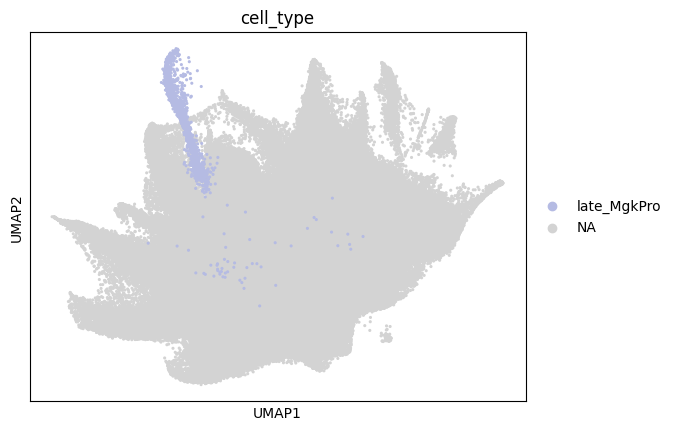

In [11]:
sc.pl.umap(adata_without_LPHO012, color="cell_type", s=20, groups=["late_MgkPro"])

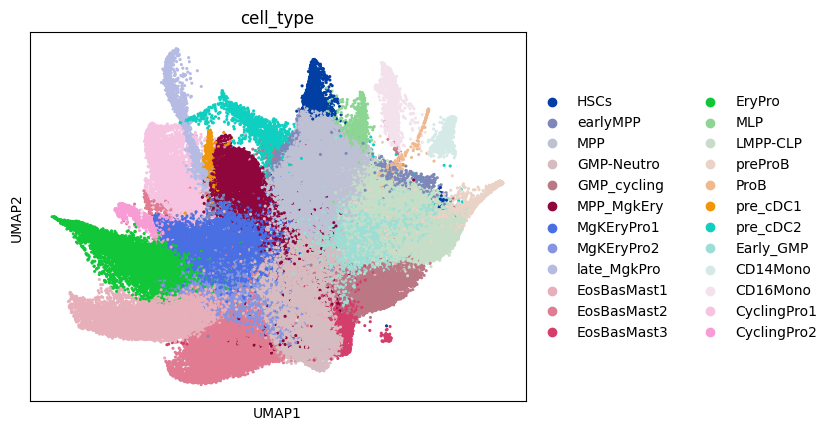

In [12]:
sc.pl.umap(adata_without_LPHO012, color="cell_type", s=20)

In [29]:
import numpy as np
import pandas as pd

In [26]:
unique_cell_types = np.unique(adata_without_LPHO012.obs.cell_type, return_counts=True)
unique_cell_types_dict = dict(zip(unique_cell_types[0], unique_cell_types[1]))

In [35]:
pd.DataFrame([unique_cell_types_dict]).T

,0
CD14Mono,584
CD16Mono,1208
CyclingPro1,10050
CyclingPro2,930
Early_GMP,35862
EosBasMast1,16824
EosBasMast2,31603
EosBasMast3,1932
EryPro,15758
GMP-Neutro,71745
